In [31]:
import os

os.chdir(r"D:\Human_Activity_Recognition")

print("Now in:", os.getcwd())

Now in: D:\Human_Activity_Recognition


In [ ]:
#import libraries
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
#load data
from src.preprocess import load_data, preprocess

train_df, test_df = load_data()

In [ ]:
#EDA
print("TRAIN SHAPE:", train_df.shape)
print("TEST SHAPE:", test_df.shape)

print("\nMissing Values:", train_df.isnull().sum().sum())
print("Duplicates:", train_df.duplicated().sum())

print("\nConstant Columns:", len(train_df.columns[train_df.nunique() <= 1]))

TRAIN SHAPE: (7352, 563)
TEST SHAPE: (2947, 563)

Missing Values: 0
Duplicates: 0

Constant Columns: 0


In [36]:
print(train_df.columns)

Index(['tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-mean()-Z',
       'tBodyAcc-std()-X', 'tBodyAcc-std()-Y', 'tBodyAcc-std()-Z',
       'tBodyAcc-mad()-X', 'tBodyAcc-mad()-Y', 'tBodyAcc-mad()-Z',
       'tBodyAcc-max()-X',
       ...
       'fBodyBodyGyroJerkMag-kurtosis()', 'angle(tBodyAccMean,gravity)',
       'angle(tBodyAccJerkMean),gravityMean)',
       'angle(tBodyGyroMean,gravityMean)',
       'angle(tBodyGyroJerkMean,gravityMean)', 'angle(X,gravityMean)',
       'angle(Y,gravityMean)', 'angle(Z,gravityMean)', 'subject', 'Activity'],
      dtype='object', length=563)


In [37]:
#class distribution
print(train_df["Activity"].value_counts())

Activity
LAYING                1407
STANDING              1374
SITTING               1286
WALKING               1226
WALKING_UPSTAIRS      1073
WALKING_DOWNSTAIRS     986
Name: count, dtype: int64


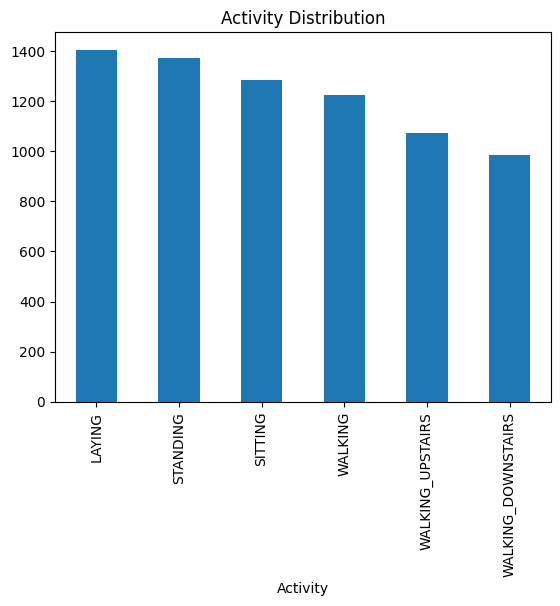

In [38]:
#data visualization
import matplotlib.pyplot as plt

train_df["Activity"].value_counts().plot(kind="bar")
plt.title("Activity Distribution")
plt.show()

In [39]:
#preprocess data
X_train, X_test, X_train_scaled, X_test_scaled, y_train, y_test, scaler = preprocess(train_df, test_df)

In [ ]:
#checking multinomial logistic regression
import sklearn
print("Scikit-Learn Version:", sklearn.__version__)

from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

print(model.get_params())

Scikit-Learn Version: 1.8.0
{'C': 1.0, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': 0.0, 'max_iter': 1000, 'n_jobs': None, 'penalty': 'deprecated', 'random_state': None, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}


In [40]:
#load trained models
import joblib

rf_model = joblib.load("models/rf_tuned.pkl")
svm_model = joblib.load("models/svm_tuned.pkl")
lr_model = joblib.load("models/lr_tuned.pkl")
dt_model = joblib.load("models/dt_tuned.pkl")

c:\Users\Administrator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Administrator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator RandomForestClassifier from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
c:\Users\Administrator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py:463: InconsistentVe

In [41]:
#random forest results
rf_train_pred = rf_model.predict(X_train)
rf_test_pred = rf_model.predict(X_test)

rf_train_acc = accuracy_score(y_train, rf_train_pred)
rf_test_acc = accuracy_score(y_test, rf_test_pred)

print("\n🌲 RANDOM FOREST RESULTS")
print("Train Accuracy:", rf_train_acc)
print("Test Accuracy:", rf_test_acc)
print("Overfitting Gap:", rf_train_acc - rf_test_acc)
print("Best Params:", rf_model.get_params())


🌲 RANDOM FOREST RESULTS
Train Accuracy: 1.0
Test Accuracy: 0.9273837801153716
Overfitting Gap: 0.07261621988462841
Best Params: {'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 5, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 200, 'n_jobs': None, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


In [42]:
#svm
svm_train_pred = svm_model.predict(X_train_scaled)
svm_test_pred = svm_model.predict(X_test_scaled)

svm_train_acc = accuracy_score(y_train, svm_train_pred)
svm_test_acc = accuracy_score(y_test, svm_test_pred)

print("\n🧠 SVM RESULTS")
print("Train Accuracy:", svm_train_acc)
print("Test Accuracy:", svm_test_acc)
print("Overfitting Gap:", svm_train_acc - svm_test_acc)
print("Best Params:", svm_model.get_params())


🧠 SVM RESULTS
Train Accuracy: 0.9926550598476604
Test Accuracy: 0.9616559212758737
Overfitting Gap: 0.03099913857178671
Best Params: {'C': 0.1, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'scale', 'kernel': 'linear', 'max_iter': -1, 'probability': False, 'random_state': None, 'shrinking': True, 'tol': 0.001, 'verbose': False}


In [43]:
#logistic regression
lr_train_pred = lr_model.predict(X_train_scaled)
lr_test_pred = lr_model.predict(X_test_scaled)

lr_train_acc = accuracy_score(y_train, lr_train_pred)
lr_test_acc = accuracy_score(y_test, lr_test_pred)

print("\n📈 LOGISTIC REGRESSION RESULTS")
print("Train Accuracy:", lr_train_acc)
print("Test Accuracy:", lr_test_acc)
print("Overfitting Gap:", lr_train_acc - lr_test_acc)
print("Best Params:", lr_model.get_params())


📈 LOGISTIC REGRESSION RESULTS
Train Accuracy: 0.9964635473340587
Test Accuracy: 0.9552086868001357
Overfitting Gap: 0.04125486053392302
Best Params: {'C': 1, 'class_weight': None, 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': None, 'max_iter': 1000, 'n_jobs': None, 'penalty': 'l2', 'random_state': None, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}


In [44]:
#decision tree
dt_train_pred = dt_model.predict(X_train)
dt_test_pred = dt_model.predict(X_test)

dt_train_acc = accuracy_score(y_train, dt_train_pred)
dt_test_acc = accuracy_score(y_test, dt_test_pred)

print("\n🌳 DECISION TREE RESULTS")
print("Train Accuracy:", dt_train_acc)
print("Test Accuracy:", dt_test_acc)
print("Overfitting Gap:", dt_train_acc - dt_test_acc)
print("Best Params:", dt_model.get_params())


🌳 DECISION TREE RESULTS
Train Accuracy: 1.0
Test Accuracy: 0.8595181540549711
Overfitting Gap: 0.14048184594502888
Best Params: {'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'entropy', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}


In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

In [55]:
results_table = []

In [56]:
def evaluate_model(name, model):

    if name in ["SVM", "Logistic Regression"]:
        y_pred = model.predict(X_test_scaled)
    else:
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted")
    rec = recall_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")

    # store in table
    results_table.append([name, acc, prec, rec, f1])

    return y_pred

In [57]:
#run all models
predictions = {}

for name, model in models.items():
    predictions[name] = evaluate_model(name, model)

In [58]:
import pandas as pd

results_df = pd.DataFrame(
    results_table,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1 Score"]
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.927384,0.928458,0.927384,0.927162
1,SVM,0.961656,0.962503,0.961656,0.961534
2,Logistic Regression,0.955209,0.956927,0.955209,0.955131
3,Decision Tree,0.859518,0.860328,0.859518,0.858505


In [59]:
#best model
best_row = results_df.loc[results_df["Accuracy"].idxmax()]

print("BEST MODEL:")
print(best_row)

BEST MODEL:
Model             SVM
Accuracy     0.961656
Precision    0.962503
Recall       0.961656
F1 Score     0.961534
Name: 1, dtype: object


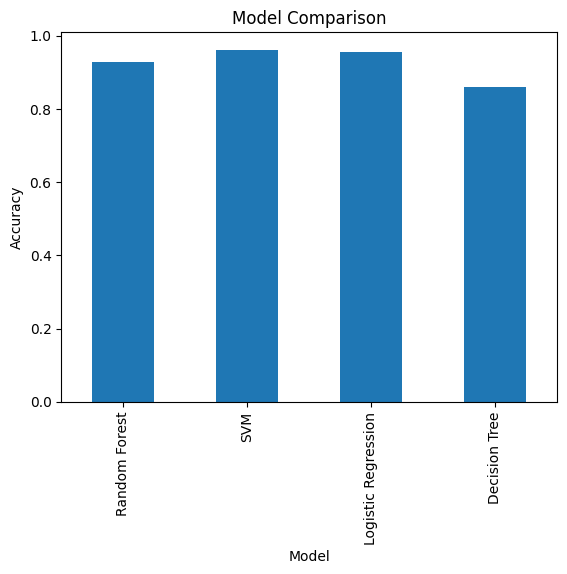

In [49]:
import matplotlib.pyplot as plt

comparison.plot(x="Model", y="Accuracy", kind="bar", legend=False)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

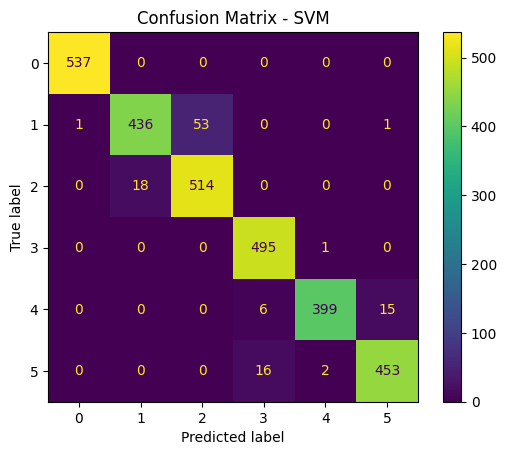

In [ ]:
#confusion matrix (best model)
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
model_map = {
    "Random Forest": rf_model,
    "SVM": svm_model,
    "Logistic Regression": lr_model,
    "Decision Tree": dt_model
}

best_model_obj = model_map[best_model]

if best_model in ["SVM", "Logistic Regression"]:
    y_pred = best_model_obj.predict(X_test_scaled)
else:
    y_pred = best_model_obj.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

ConfusionMatrixDisplay(cm).plot()
plt.title(f"Confusion Matrix - {best_model}")
plt.show()

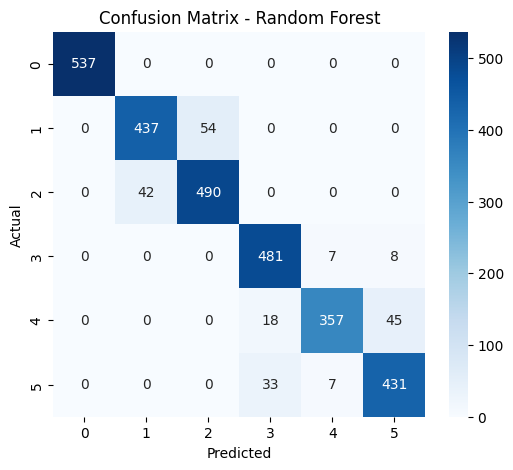

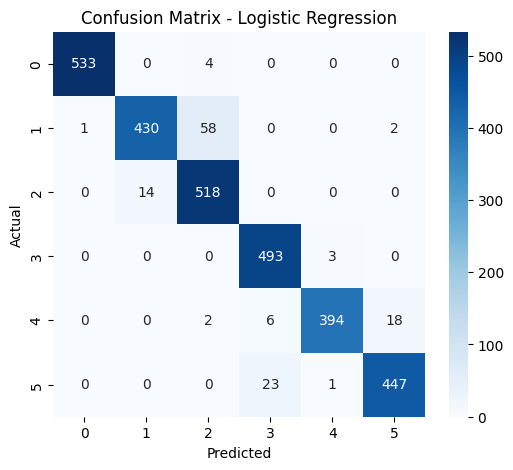

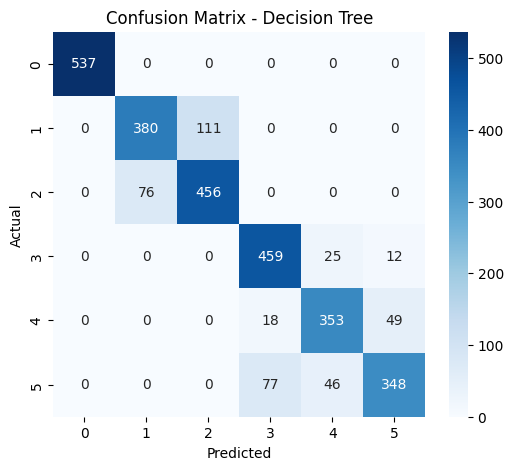

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
def plot_cm(name, model):
    
    if name in ["SVM"]:
        return  # skip SVM completely

    if name in ["Logistic Regression"]:
        y_pred = model.predict(X_test_scaled)
    else:
        y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

for name, model in models.items():
    if name != "SVM":
        plot_cm(name, model)

In [51]:
#conclusion
print(f"""
FINAL PROJECT SUMMARY:

Best Model: {best_model}
Best Accuracy: {results[best_model]:.4f}

Observations:
- Random Forest gives strong performance but slightly overfits
- SVM gives best balance of accuracy and generalization
- Logistic Regression is stable but slightly lower accuracy
- Decision Tree overfits the most

Final Decision: {best_model} is selected for deployment
""")


FINAL PROJECT SUMMARY:

Best Model: SVM
Best Accuracy: 0.9617

Observations:
- Random Forest gives strong performance but slightly overfits
- SVM gives best balance of accuracy and generalization
- Logistic Regression is stable but slightly lower accuracy
- Decision Tree overfits the most

Final Decision: SVM is selected for deployment

